# Sampling and visualizing a nested copula

Build a two-level **Clayton-over-Frank** copula (one root, three sectors of
two leaves), draw samples with the Marshall-Olkin algorithm, and look at both
the model's tree structure and the dependence in the samples.

In [1]:
import jax.numpy as jnp
import jax.random as jrandom
import numpy as np
import matplotlib.pyplot as plt

from acopula import compile_model, copula, marginal


class Uniform:
    def quantile(self, u): return u
    def cdf(self, x): return x
    def log_prob(self, x): return 0.0


@copula
class Clayton:
    theta: float
    def generator(self, t):
        return (1.0 + t) ** (-1.0 / self.theta)


@copula
class Frank:
    theta: float
    def generator(self, t):
        return -jnp.log1p(jnp.expm1(-self.theta) * jnp.exp(-t)) / self.theta

## The model

A Clayton root over three Frank sectors, each with two uniform leaves.

In [2]:
def model(params, u):
    root = Clayton(params[0])
    sector = Frank(params[1])
    return root(
        sector(marginal(Uniform(), obs=u[i, j]) for j in range(2))
        for i in range(3)
    )


params = jnp.array([2.0, 5.0])   # theta_root (Clayton), theta_sector (Frank)
cm = compile_model(model, template=params)

## The copula tree

`CompiledModel.visualize()` draws the structural graph — root and sector
copulas in blue, leaves in orange.

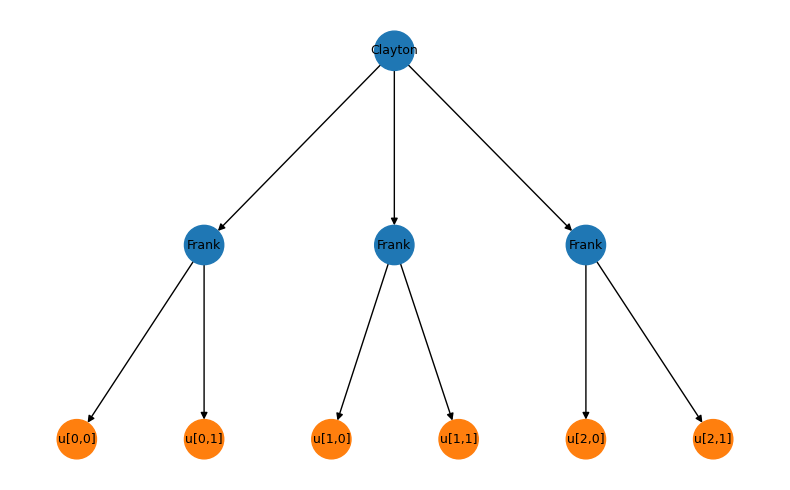

In [3]:
fig, ax = cm.visualize(include_leaves=True, layout="hierarchical")
fig.set_size_inches(8, 5)
plt.show()

## Sample, and look at the margins

Draw 2000 samples with the Marshall-Olkin sampler, then plot the pairwise
scatter. Within-sector pairs (`u[i,0]`–`u[i,1]`) are visibly more dependent
than across-sector pairs — that's the nesting.

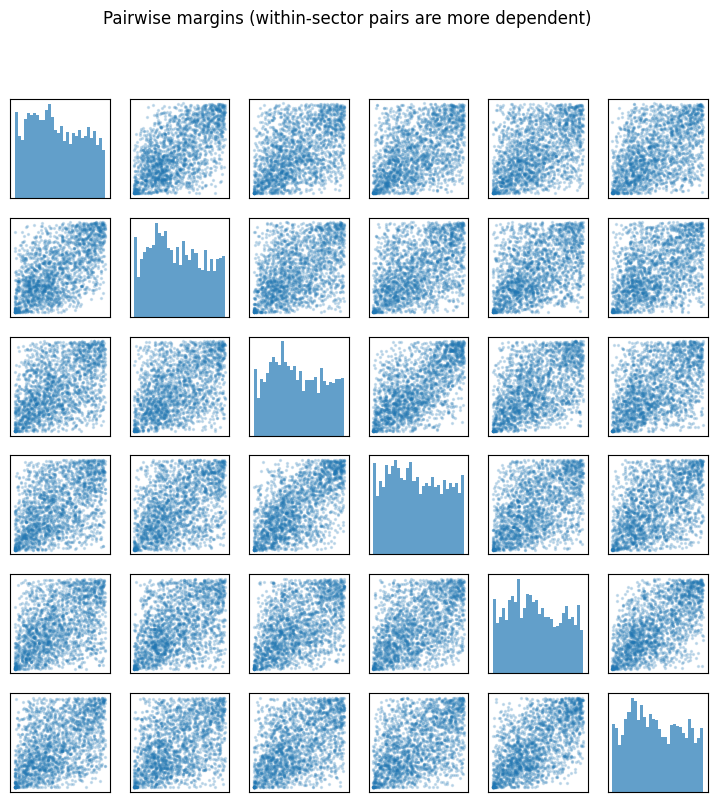

In [4]:
samples = cm.sample(jrandom.PRNGKey(0), 2000, params, method="marshall_olkin")
s = np.asarray(samples).reshape(samples.shape[0], -1)   # (n, 6)
d = s.shape[1]

fig, axes = plt.subplots(d, d, figsize=(9, 9))
for i in range(d):
    for j in range(d):
        ax = axes[i, j]
        if i == j:
            ax.hist(s[:, i], bins=30, color="tab:blue", alpha=0.7)
        else:
            ax.scatter(s[:, j], s[:, i], s=2, alpha=0.2, color="tab:blue")
        ax.set_xticks([]); ax.set_yticks([])
fig.suptitle("Pairwise margins (within-sector pairs are more dependent)")
plt.show()